**DSCB230 Sommersemester 2026**

# Hausarbeit - Unternehmensanaylse anhand des Aktienkurses
Data Science Portfolioprojekt

Gruppe | Studierende 1 | Studierende 2 |
------ | ------ | ------ |
`Foxtrot` | `Ivan Pedzin` | `Maximilian Hutter` |

## Business Case

Es sollen verschiedene Unternehmen, am Beispiel Apple, Microsoft und Samsung, auf Basis ihres Aktienkurses verglichen werden, um Investitionsentscheidungen zu treffen (Zeitraum 2000 - Jetzt). Alle Kurse werden in US-Dollar (USD) betrachtet, da die zugrunde liegenden Aktien an US-Börsen notieren.

Dabei werden speziell folgende Punkte untersucht:
- Allgemeiner grafischer Vergleich der Aktienkurse
- Rendite
- Volatilität
- gleitende Durchschnitte
- Verhalten in Krisenzeiten
- Am Beispiel Intel: Entwicklung einer Investition von 1.000 USD vom 04.05.2026 (2. Zwischenpräsentation) bis zur Abschlusspräsentation

## Datenerfassung und Datenvorverarbeitung

### Download des Datensatzes (Yahoo Finance API)

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import streamlit as st
import plotly.graph_objects as go
from datetime import datetime
import pandas as pd
import numpy as np

heute = datetime.now().strftime('%Y-%m-%d')

# Aktien Dictionary, weiter Aktien einfach ergänzen
aktien = {
    "Apple":     "AAPL",
    "Microsoft": "MSFT",
    "Samsung":   "SMSN.IL"
}

In [2]:
# Daten von 2000
daten = {}
for name, ticker in aktien.items():
    daten[name] = yf.Ticker(ticker).history(start="2000-01-01", end=heute)

### Erster Überblick über die Daten

In [3]:
for name, df in daten.items():
    print(name)
    display(df.head())

Apple


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2000-01-03 00:00:00-05:00,0.784870,0.841934,0.761015,0.837724,535796800,0.0,0.0
2000-01-04 00:00:00-05:00,0.810128,0.827901,0.757273,0.767096,512377600,0.0,0.0
2000-01-05 00:00:00-05:00,0.776450,0.827434,0.770838,0.778321,778321600,0.0,0.0
2000-01-06 00:00:00-05:00,0.794225,0.800773,0.710966,0.710966,767972800,0.0,0.0
2000-01-07 00:00:00-05:00,0.722192,0.755870,0.714709,0.744644,460734400,0.0,0.0


Microsoft


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2000-01-03 00:00:00-05:00,35.690694,36.070787,34.056296,35.443634,53228400,0.0,0.0
2000-01-04 00:00:00-05:00,34.531392,35.614655,34.132295,34.246323,54119000,0.0,0.0
2000-01-05 00:00:00-05:00,33.790208,35.386596,33.258079,34.607407,64059600,0.0,0.0
2000-01-06 00:00:00-05:00,34.113282,34.626406,32.954000,33.448120,54976600,0.0,0.0
2000-01-07 00:00:00-05:00,33.030023,34.132291,32.630926,33.885231,62013600,0.0,0.0


Samsung


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2001-05-14 00:00:00+01:00,63.990910,63.990910,63.094678,63.453171,197500,0.0,0.0
2001-05-15 00:00:00+01:00,62.549806,63.596604,62.377731,62.599995,122000,0.0,0.0
2001-05-16 00:00:00+01:00,61.660727,62.571296,60.585250,60.764496,278900,0.0,0.0
2001-05-17 00:00:00+01:00,63.818852,64.442626,62.377710,64.163002,364300,0.0,0.0
2001-05-18 00:00:00+01:00,63.202217,64.528638,60.864845,64.119957,199100,0.0,0.0


### Datenbereinigung

#### Fehlende Werte checken

In [4]:
for name, df in daten.items():
    print(f'{name}:')
    print(df.isnull().sum())
#mit isnull schauen ob zellen leer sind und ergebnis (True/False) aller zellen zusammenrechnen


Apple:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64
Microsoft:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64
Samsung:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


#### Duplikate Checken

In [5]:
for name, df in daten.items():
    print(f'{name}: {df.index.duplicated().sum()} Duplikate')
# schaut ob ein datum (index) doppelt vorkommt

Apple: 0 Duplikate
Microsoft: 0 Duplikate
Samsung: 0 Duplikate


#### Samsung GDR in einzel Aktien umrechnen

In [6]:
# Samsung Kurse durch 25 teilen (GDR → Einzelaktie: 1 GDR = 25 Stammaktien)
for col in ["Close", "Open", "High", "Low"]:
    daten["Samsung"][col] = daten["Samsung"][col] / 25

## Analyse der Daten

### Kursvergleiche

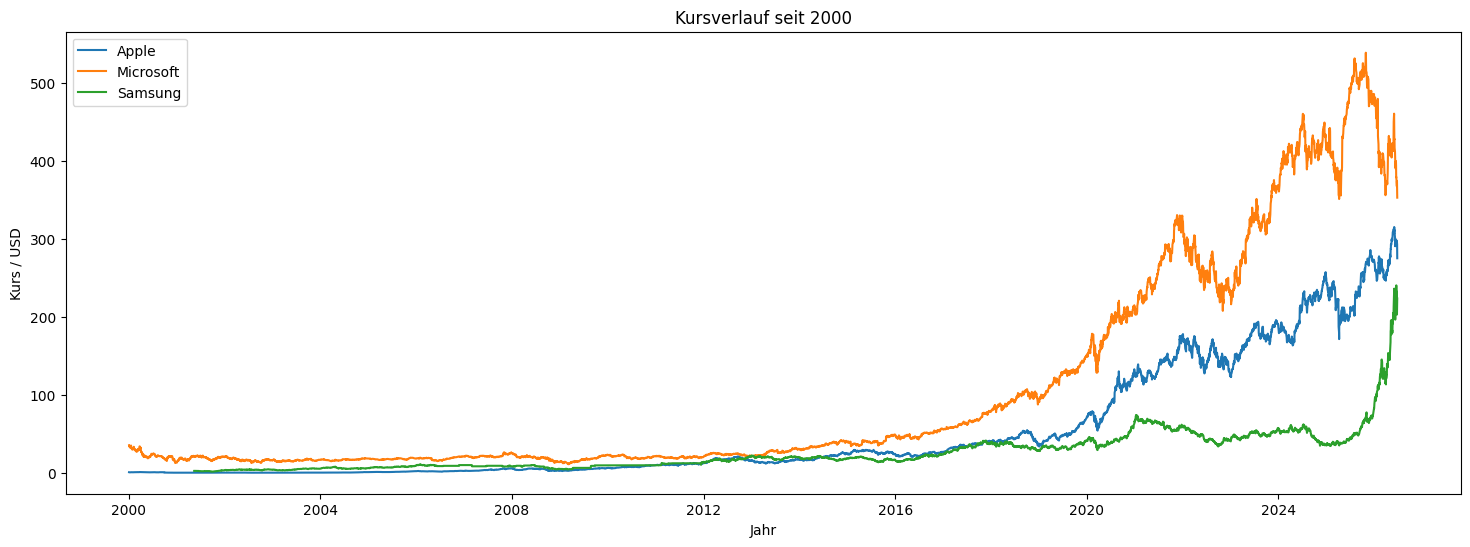

In [7]:
plt.figure(figsize=(18, 6))
for name, df in daten.items():
    plt.plot(df["Close"], label=name)
plt.title("Kursverlauf seit 2000")
plt.xlabel("Jahr")
plt.ylabel("Kurs / USD")
plt.legend()
plt.show()


### Rendite

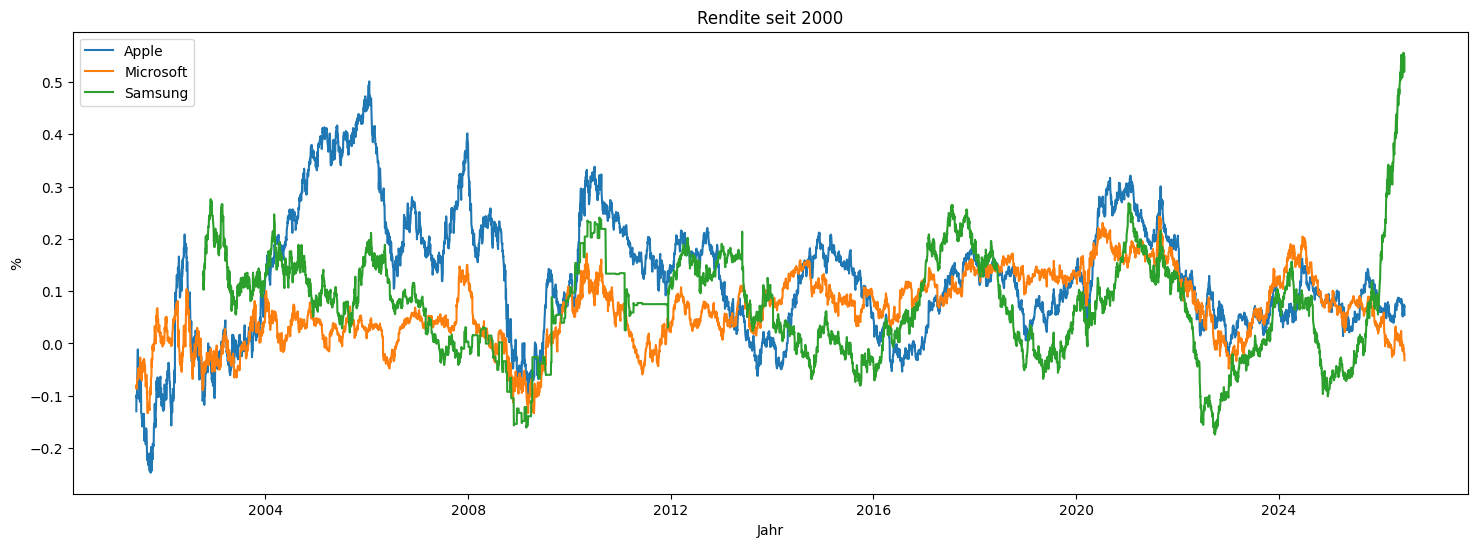

In [8]:
for name, df in daten.items():
    daten[name]["Rendite"] = daten[name]["Close"].pct_change() * 100

plt.figure(figsize=(18, 6))
for name, df in daten.items():
    #plt.plot(df["Rendite"], label=name) jeder tag geplottet zu unubersichtlich
    plt.plot(df["Rendite"].rolling(365).mean(), label=name) #Jahres durchschnitt
plt.title("Rendite seit 2000")
plt.xlabel("Jahr")
plt.ylabel("%")
plt.legend()
plt.show()

### Volatilität

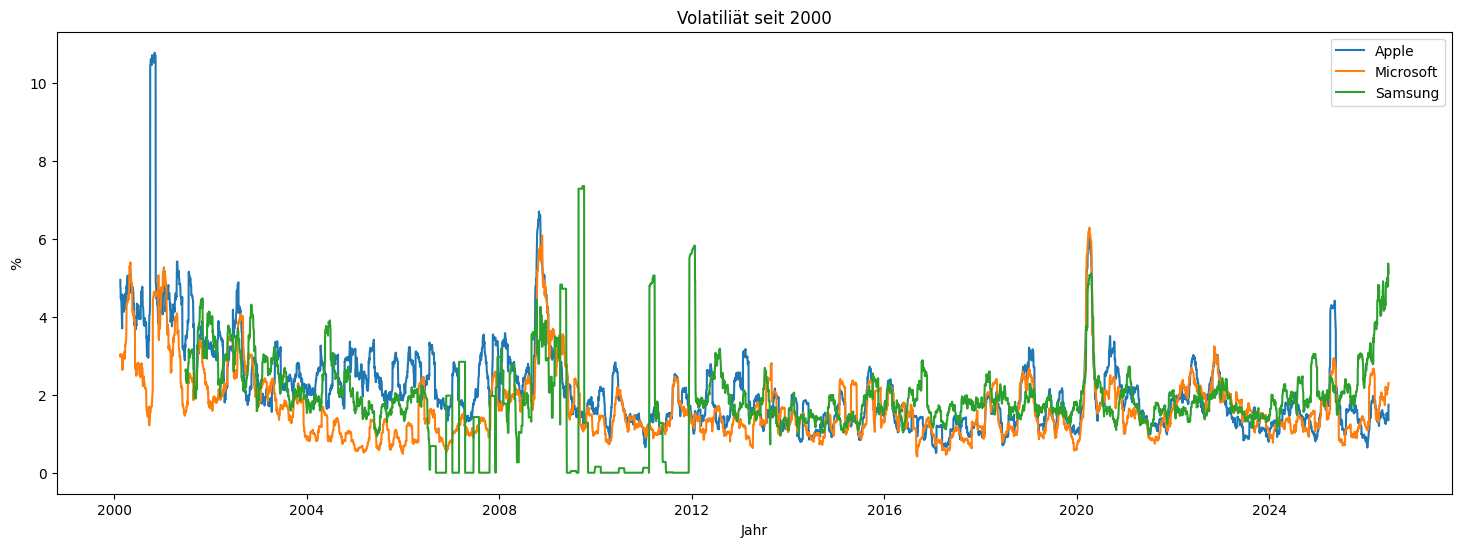

In [9]:
for name, df in daten.items():
    daten[name]["Volatilitaet"] = daten[name]["Rendite"].rolling(30).std() 

plt.figure(figsize=(18, 6))
for name, df in daten.items():
    plt.plot(df["Volatilitaet"], label=name)
plt.title("Volatiliät seit 2000")
plt.xlabel("Jahr")
plt.ylabel("%")
plt.legend()
plt.show()

### Gleitender Durchschnitt

####  Einfacher gleitender Durchschnitt (SMA)

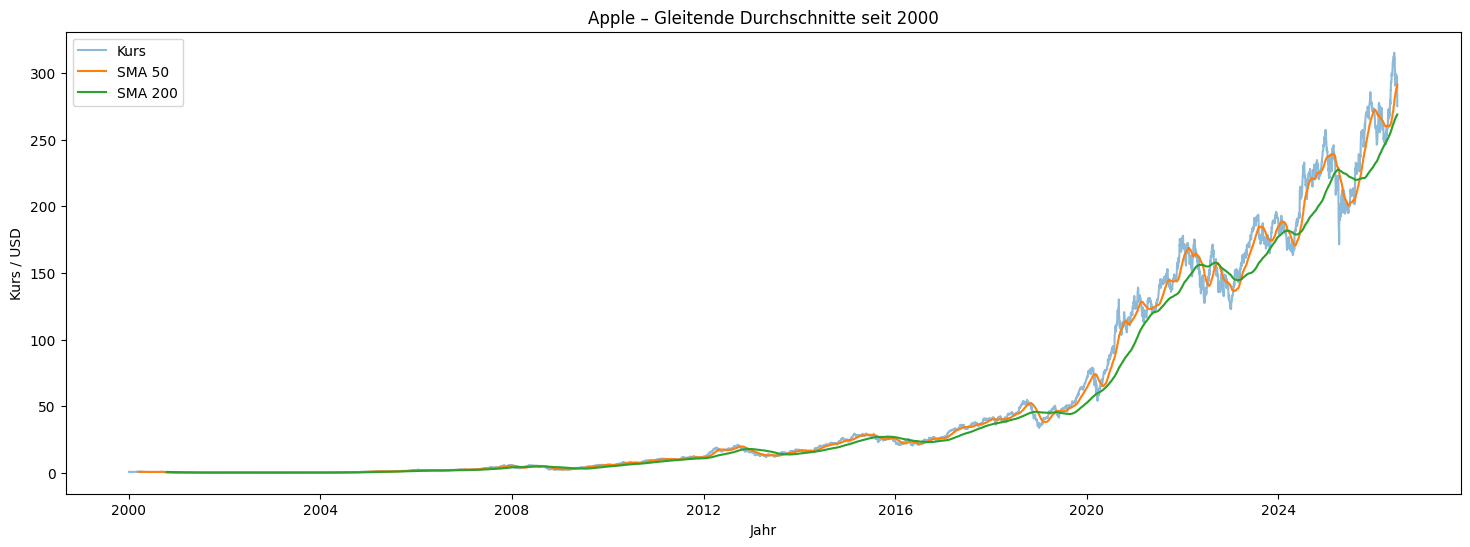

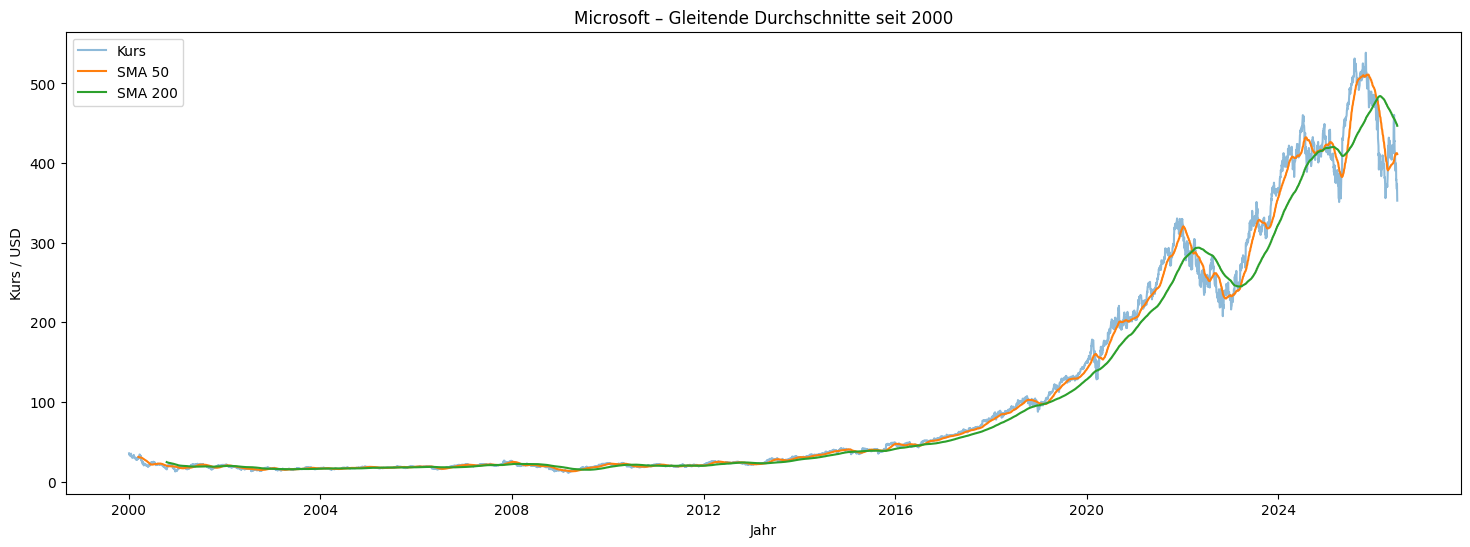

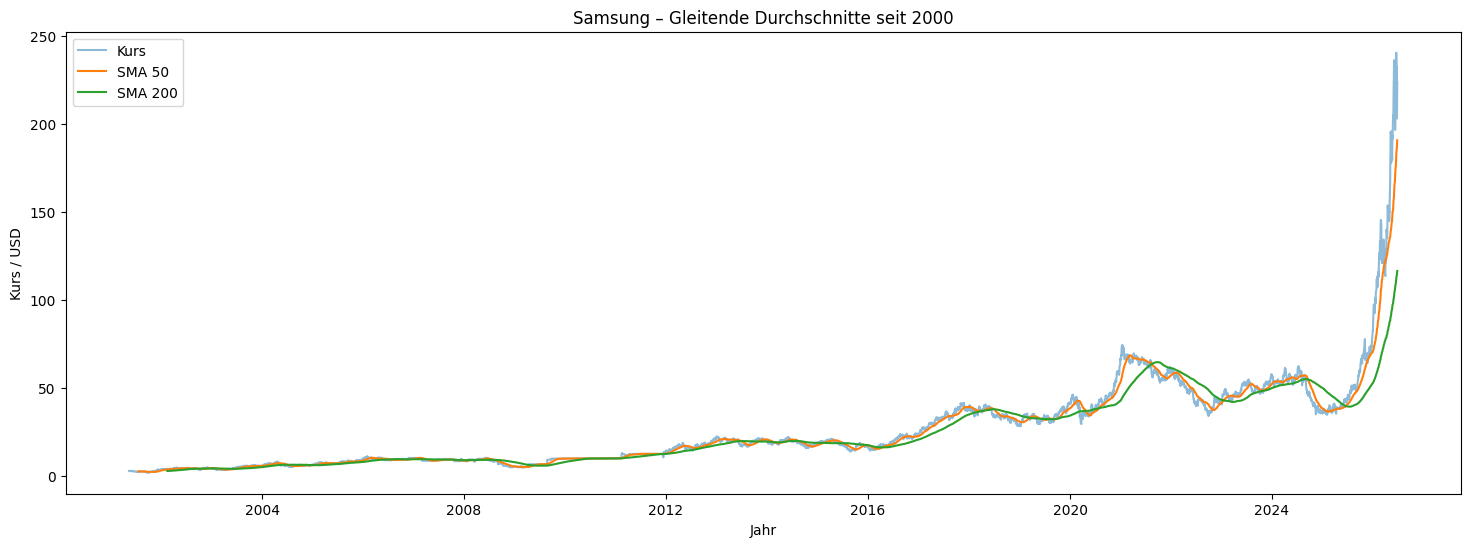

In [10]:
for name, df in daten.items():
    daten[name]["SMA_50"] = daten[name]["Close"].rolling(50).mean()
    daten[name]["SMA_200"] = daten[name]["Close"].rolling(200).mean()

for name, df in daten.items():
    plt.figure(figsize=(18, 6))
    plt.plot(df["Close"], label="Kurs", alpha=0.5)
    plt.plot(df["SMA_50"], label="SMA 50")
    plt.plot(df["SMA_200"], label="SMA 200")
    plt.title(f"{name} – Gleitende Durchschnitte seit 2000")
    plt.xlabel("Jahr")
    plt.ylabel("Kurs / USD")
    plt.legend()
    plt.show()

#### Exponentieller gleitender Durchschnitt (EMA)

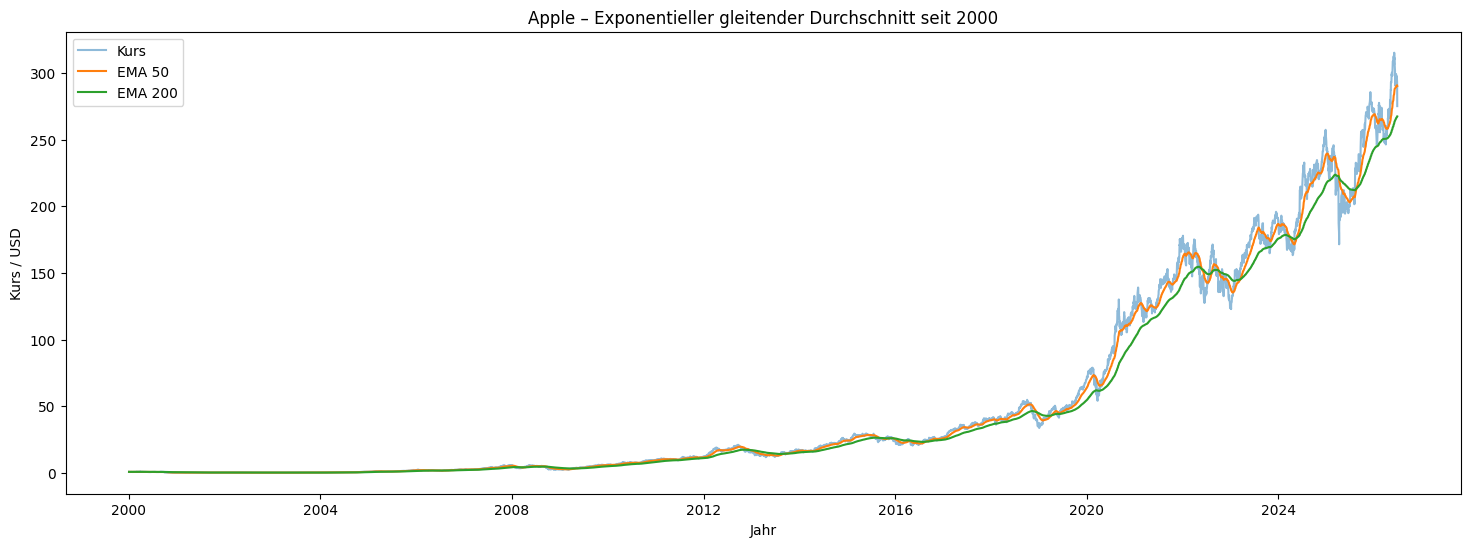

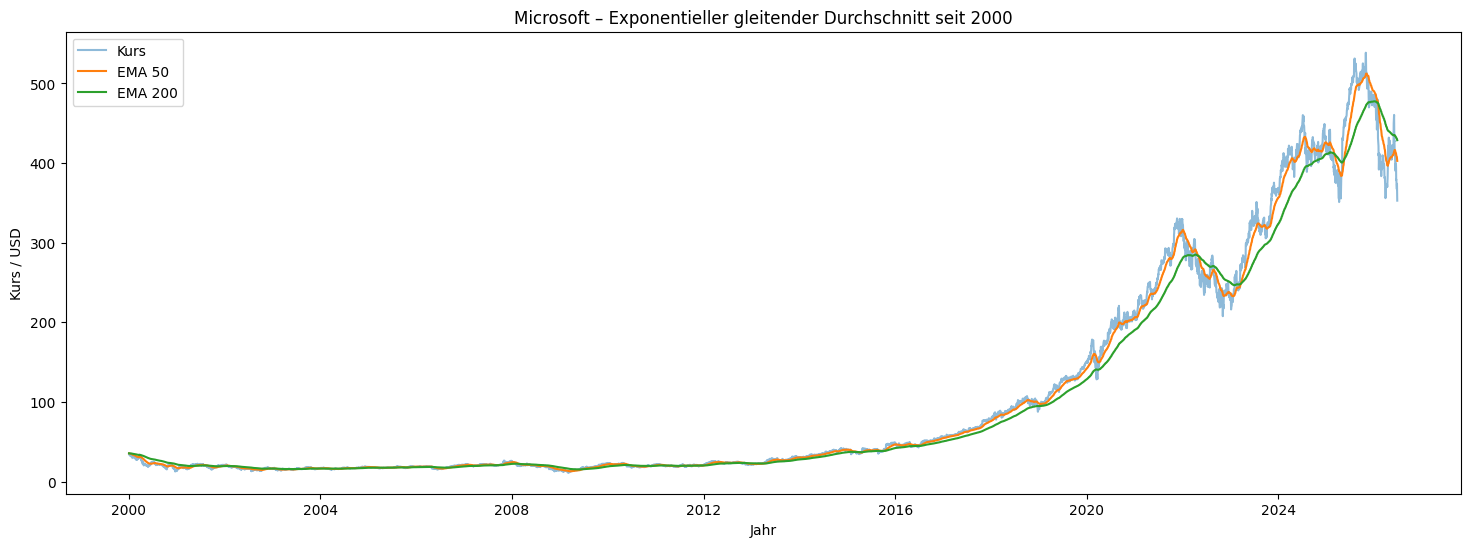

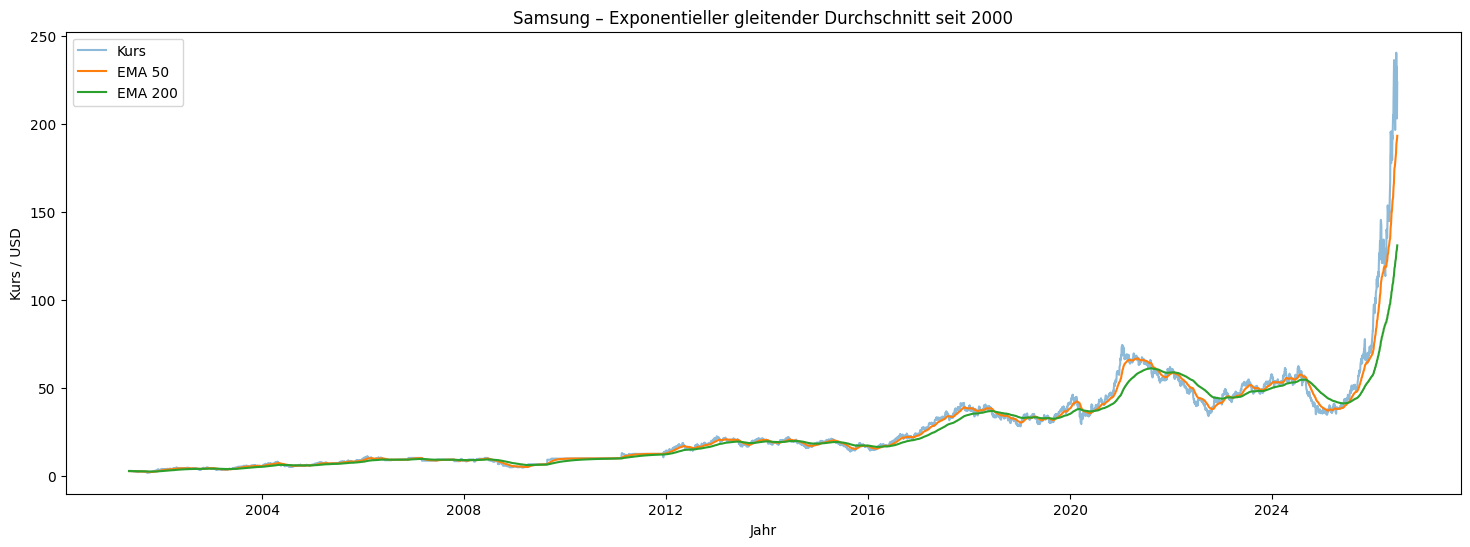

In [11]:
for name, df in daten.items():
    daten[name]["EMA_50"] = daten[name]["Close"].ewm(span=50, adjust=False).mean()
    daten[name]["EMA_200"] = daten[name]["Close"].ewm(span=200, adjust=False).mean()

for name, df in daten.items():
    plt.figure(figsize=(18, 6))
    plt.plot(df["Close"], label="Kurs", alpha=0.5)
    plt.plot(df["EMA_50"], label="EMA 50")
    plt.plot(df["EMA_200"], label="EMA 200")
    plt.title(f"{name} – Exponentieller gleitender Durchschnitt seit 2000")
    plt.xlabel("Jahr")
    plt.ylabel("Kurs / USD")
    plt.legend()
    plt.show()

#### Verhalten in Krisenzeiten

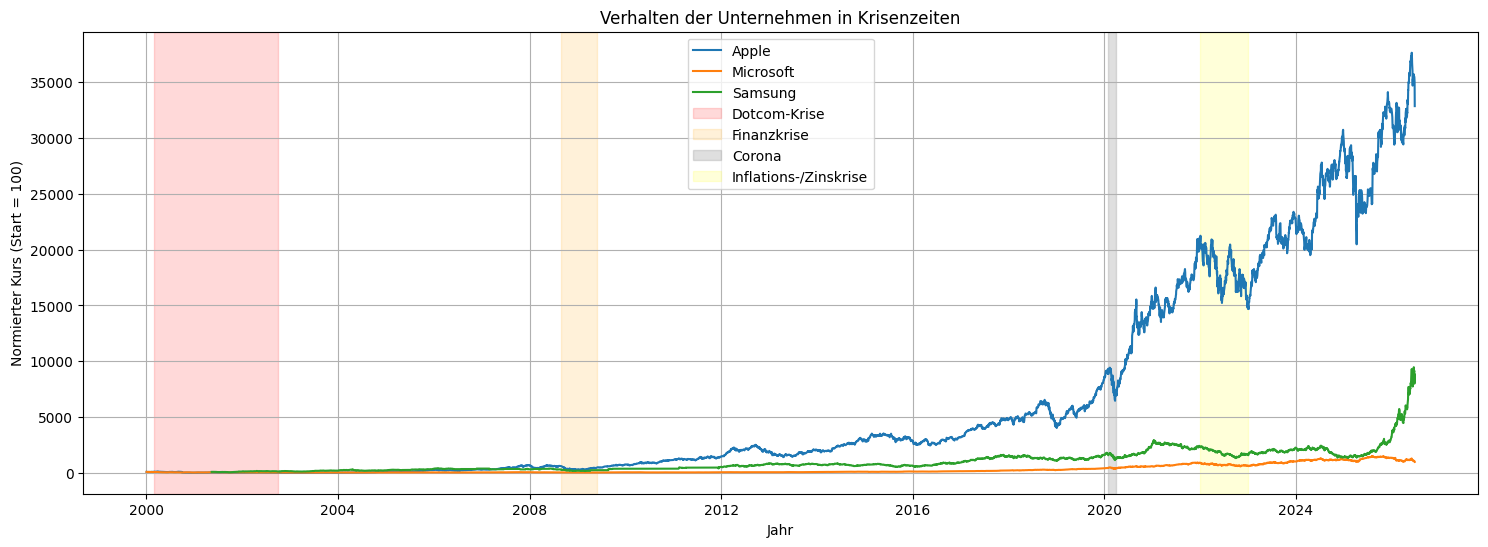

In [12]:
# Alle Aktien auf denselben Startwert normieren
plt.figure(figsize=(18, 6))

for name, df in daten.items():
    normiert = df["Close"] / df["Close"].iloc[0] * 100
    plt.plot(df.index, normiert, label=name)

# Krisen markieren
plt.axvspan(pd.Timestamp("2000-03-01"), pd.Timestamp("2002-10-01"),
            color="red", alpha=0.15, label="Dotcom-Krise")

plt.axvspan(pd.Timestamp("2008-09-01"), pd.Timestamp("2009-06-01"),
            color="orange", alpha=0.15, label="Finanzkrise")

plt.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-04-01"),
            color="gray", alpha=0.25, label="Corona")

plt.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"),
            color="yellow", alpha=0.15, label="Inflations-/Zinskrise")

plt.title("Verhalten der Unternehmen in Krisenzeiten")
plt.xlabel("Jahr")
plt.ylabel("Normierter Kurs (Start = 100)")
plt.legend()
plt.grid(True)

plt.show()

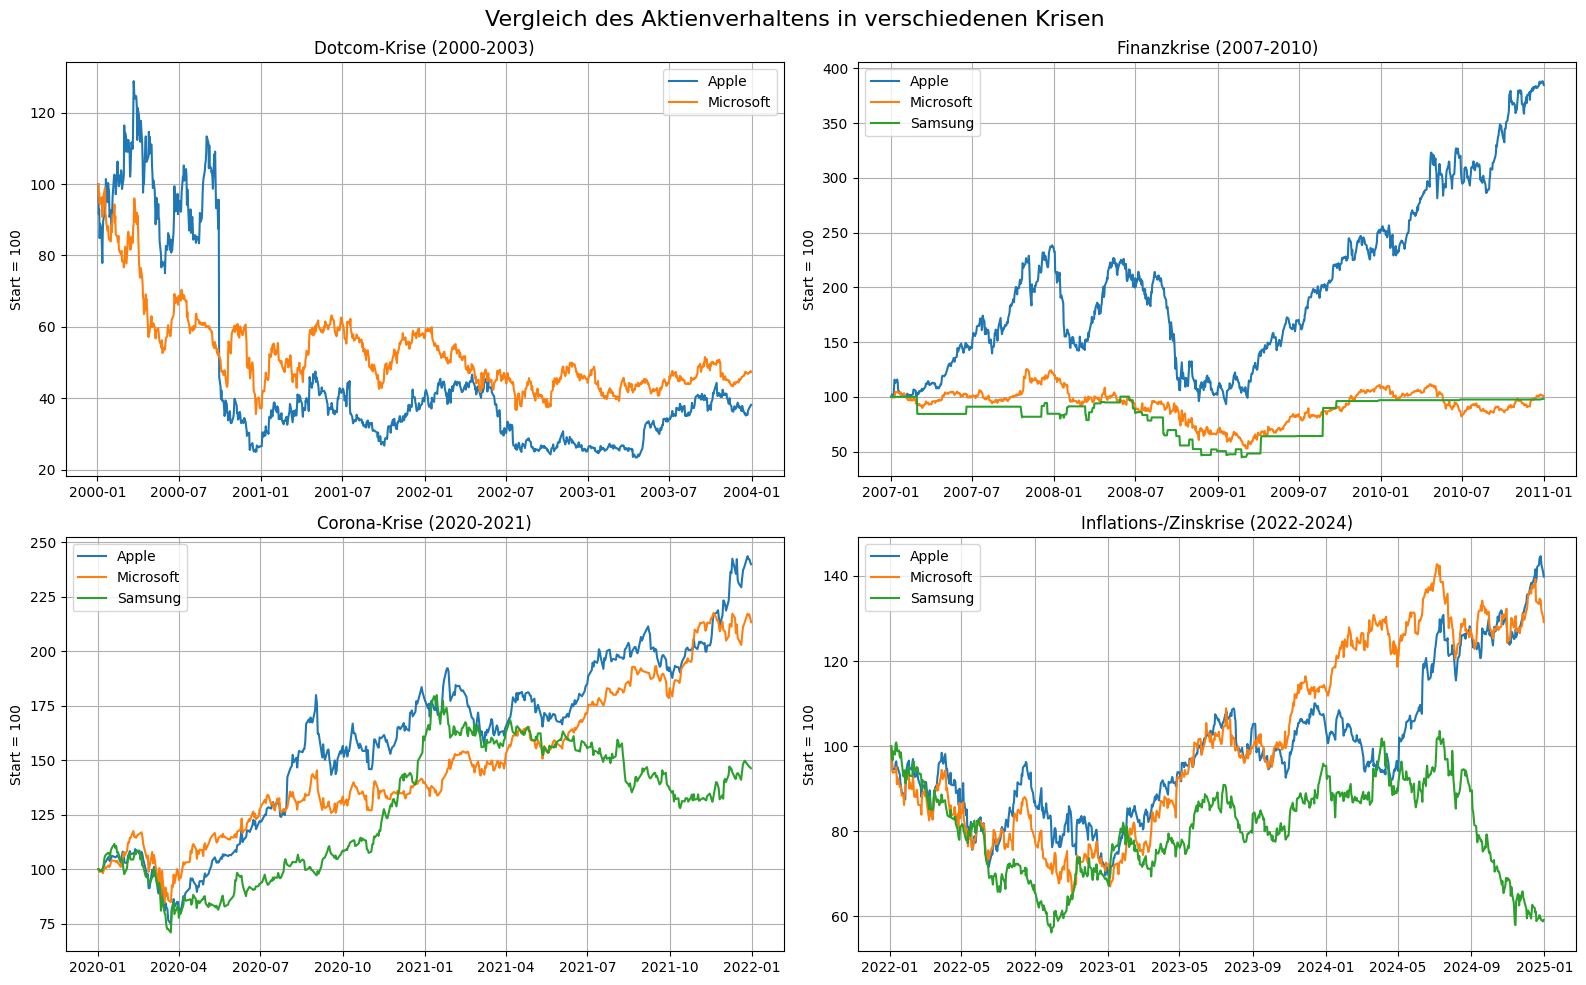

In [13]:
krisen = {
    "Dotcom-Krise (2000-2003)": ("2000-01-01", "2003-12-31"),
    "Finanzkrise (2007-2010)": ("2007-01-01", "2010-12-31"),
    "Corona-Krise (2020-2021)": ("2020-01-01", "2021-12-31"),
    "Inflations-/Zinskrise (2022-2024)": ("2022-01-01", "2024-12-31")
}


fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes = axes.flatten()

for ax, (titel, (start, ende)) in zip(axes, krisen.items()):

    for name, df in daten.items():
        if titel == "Dotcom-Krise (2000-2003)" and name == "Samsung":
            continue

        krise_df = df.loc[start:ende]

        normiert = (
            krise_df["Close"]
            / krise_df["Close"].iloc[0]
            * 100
        )

        ax.plot(
            krise_df.index,
            normiert,
            label=name
        )

    ax.set_title(titel)
    ax.set_ylabel("Start = 100")
    ax.grid(True)

for ax in axes:
    ax.legend()

plt.suptitle(
    "Vergleich des Aktienverhaltens in verschiedenen Krisen",
    fontsize=16
)

plt.tight_layout()

plt.show()


In [14]:
krisen = {
    "Dotcom-Krise": ("2000-01-01", "2003-12-31"),
    "Finanzkrise": ("2007-01-01", "2010-12-31"),
    "Corona-Krise": ("2020-01-01", "2021-12-31"),
    "Inflations-/Zinskrise": ("2022-01-01", "2024-12-31")
}

ergebnisse = []

for krise, (start, ende) in krisen.items():

    for name, df in daten.items():
        if krise == "Dotcom-Krise" and name == "Samsung":
            continue

        krise_df = df.loc[start:ende]

        startkurs = krise_df["Close"].iloc[0]
        tiefstkurs = krise_df["Close"].min()
        höchstkurs = krise_df["Close"].max()
        endkurs = krise_df["Close"].iloc[-1]

        verlust = ((tiefstkurs - startkurs) / startkurs) * 100
        gewinn = ((endkurs - startkurs) / startkurs) * 100

        ergebnisse.append([
            krise,
            name,
            round(verlust, 2),
            round(gewinn, 2)
        ])

krisen_df = pd.DataFrame(
    ergebnisse,
    columns=[
        "Krise",
        "Unternehmen",
        "Max. Verlust (%)",
        "Gesamtrendite (%)"
    ]
)

display(krisen_df)

,Krise,Unternehmen,Max. Verlust (%),Gesamtrendite (%)
0,Dotcom-Krise,Apple,-76.56,-61.82
1,Dotcom-Krise,Microsoft,-64.40,-52.62
2,Finanzkrise,Apple,-6.68,284.92
3,Finanzkrise,Microsoft,-47.27,0.81
4,Finanzkrise,Samsung,-55.36,-1.74
5,Corona-Krise,Apple,-25.12,140.00
6,Corona-Krise,Microsoft,-15.46,113.38
7,Corona-Krise,Samsung,-29.08,46.34
8,Inflations-/Zinskrise,Apple,-30.91,39.84
9,Inflations-/Zinskrise,Microsoft,-35.58,29.18


### Interpretation der Krisenanalyse

Die Ergebnisse zeigen deutliche Unterschiede im Verhalten der Unternehmen während wirtschaftlicher Krisen.

- Während der Dotcom-Krise verzeichneten sowohl Apple als auch Microsoft hohe Verluste. Samsung wurde aufgrund fehlender Daten nicht berücksichtigt.
- In der Finanzkrise zeigte Apple trotz zwischenzeitlicher Rückgänge die stärkste Erholung und erzielte mit rund 285 % die höchste Gesamtrendite.
- Während der Corona-Krise entwickelten sich alle drei Unternehmen positiv, wobei Apple erneut die höchste Rendite erzielte.
- In der Inflations- und Zinskrise erwiesen sich Apple und Microsoft als vergleichsweise widerstandsfähig, während Samsung sowohl den höchsten Verlust als auch eine negative Gesamtrendite aufwies.

Insgesamt zeigt Apple die höchste langfristige Wachstumsdynamik und die schnellste Erholung nach Krisen. Microsoft weist die stabilste Entwicklung auf und verzeichnet meist geringere Verluste. Samsung zeigt die stärksten Schwankungen und reagiert empfindlicher auf wirtschaftliche Unsicherheiten.

### Wertentwicklung einer Investition von 1.000 USD (seit 2000)

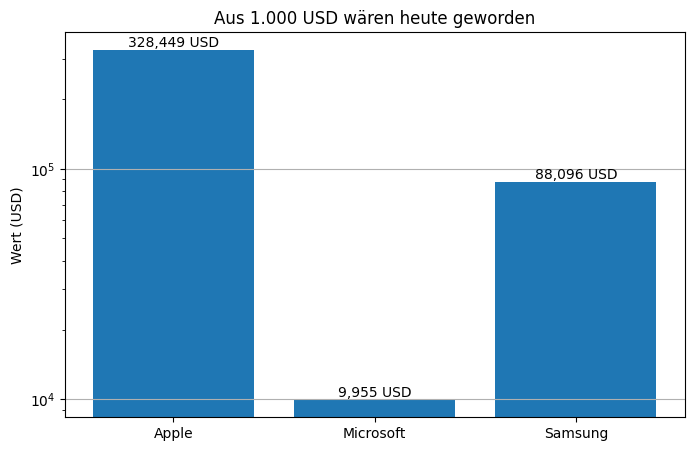

In [15]:
investition = 1000

werte = []

for name, df in daten.items():

    startkurs = df["Close"].iloc[0]
    endkurs = df["Close"].iloc[-1]

    endwert = investition * (endkurs / startkurs)

    werte.append(endwert)

plt.figure(figsize=(8,5))

bars = plt.bar(daten.keys(), werte)

plt.title("Aus 1.000 USD wären heute geworden")
plt.ylabel("Wert (USD)")
plt.grid(axis="y")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{y:,.0f} USD",
        ha="center",
        va="bottom"
    )
plt.yscale("log")
plt.show()

### Fallbeispiel Intel: Investition von 1.000 USD seit der 2. Zwischenpräsentation

Als zusätzliches Fallbeispiel wird betrachtet, wie sich eine Investition von 1.000 USD in die Intel-Aktie (INTC) seit der 2. Zwischenpräsentation (04.05.2026) bis zur Abschlusspräsentation entwickelt hätte. Anders als die langfristige Betrachtung seit 2000 zeigt dieser kurze Zeithorizont, wie stark kurzfristige Kursschwankungen eine Investitionsentscheidung beeinflussen.

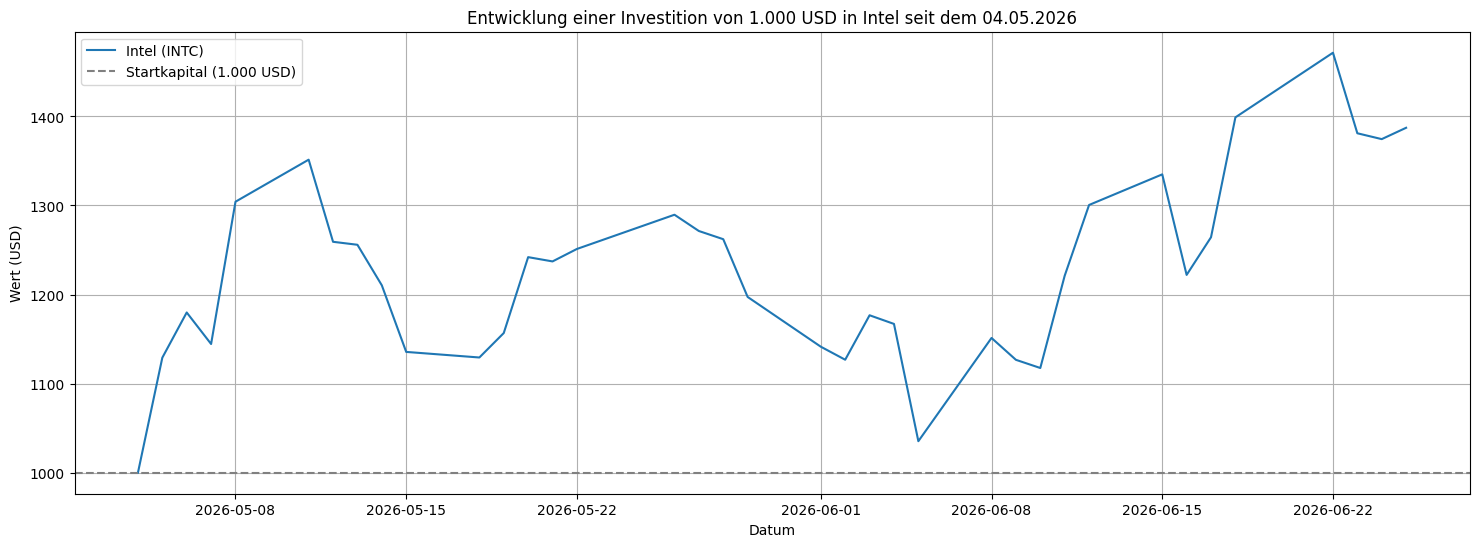

Startkurs (04.05.2026):           95.78 USD
Aktueller Wert der Investition:    1,387.24 USD
Rendite seit 04.05.2026:           +38.72 %


In [16]:
# 1.000 USD in Intel (INTC) investiert am 04.05.2026 (2. Zwischenpräsentation)
intel = yf.Ticker("INTC").history(start="2026-05-04", end=heute)

investition = 1000
startkurs = intel["Close"].iloc[0]
intel["Investitionswert"] = investition * (intel["Close"] / startkurs)

endwert = intel["Investitionswert"].iloc[-1]
rendite = (endwert - investition) / investition * 100

plt.figure(figsize=(18, 6))
plt.plot(intel.index, intel["Investitionswert"], label="Intel (INTC)")
plt.axhline(investition, color="gray", linestyle="--", label="Startkapital (1.000 USD)")
plt.title("Entwicklung einer Investition von 1.000 USD in Intel seit dem 04.05.2026")
plt.xlabel("Datum")
plt.ylabel("Wert (USD)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Startkurs (04.05.2026):           {startkurs:,.2f} USD")
print(f"Aktueller Wert der Investition:    {endwert:,.2f} USD")
print(f"Rendite seit 04.05.2026:           {rendite:+.2f} %")

_Hinweis: Nach dem Ausführen der Zelle hier die konkrete Entwicklung (Start-/Endwert, Rendite, auffällige Bewegungen) in eigenen Worten interpretieren._

## Lessons Learned